### Generic SSL Preprocessing

This notebook runs the MediaPipe Hands preprocessing pipeline for any
Sinhala Sign Language dataset under `dataset/ssl-*`.

- Reads videos from `dataset/<SSL_NAME>/<label>/*.MOV|*.MP4|*.AVI`
- Extracts hand landmarks with MediaPipe
- Wrist-normalises landmarks
- Builds fixed-length sequences with a sliding window
- Saves a pickle under `dataset/processed/<SSL_NAME>/<base_name>_sequences.pkl`

In [2]:
from pathlib import Path

# Name of the dataset directory under `dataset/`
# e.g. "ssl-alphabet-converted", "ssl-numbers", etc.
SSL_NAME = "ssl-adjectives"  # change this per dataset

# For alphabet we only used 1 hand; for others we use 2
MAX_NUM_HANDS = 1 if SSL_NAME == "ssl-alphabet-converted" else 2

# Sequence configuration (should match training & inference)
SEQ_LEN = 30
STRIDE = 5

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("C:/Redmi")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.ssl_preprocessing import run_for_dataset

output_path = run_for_dataset(
    ssl_name=SSL_NAME,
    max_num_hands=MAX_NUM_HANDS,
    seq_len=SEQ_LEN,
    stride=STRIDE,
)

print("Saved preprocessed dataset to:", output_path)

=== Preprocessing dataset 'ssl-adjectives' ===
Dataset dir   : C:\Redmi\dataset\ssl-adjectives
Processed dir : C:\Redmi\dataset\processed\ssl-adjectives
MediaPipe hand_landmarker exists at C:\Redmi\models\hand_landmarker.task
Found 443 videos in C:\Redmi\dataset\ssl-adjectives
  Bad :   32 detected /   32 total frames  (100.0%)
  Bad :   64 detected /   64 total frames  (100.0%)
  Bad :   96 detected /   96 total frames  (100.0%)
  Bad :  120 detected /  128 total frames  (93.8%)
  Beautiful :   29 detected /   32 total frames  (90.6%)
  Beautiful :   46 detected /   64 total frames  (71.9%)
  Beautiful :   61 detected /   96 total frames  (63.5%)
  Beautiful :   78 detected /  128 total frames  (60.9%)
  Beautiful :   87 detected /  159 total frames  (54.7%)
  Beautiful :  103 detected /  191 total frames  (53.9%)
  Beautiful :  117 detected /  223 total frames  (52.5%)
  Beautiful :  132 detected /  255 total frames  (51.8%)
  Beautiful :  142 detected /  287 total frames  (49.5%)
  

Train shape: (303, 30, 126)
Val shape  : (65, 30, 126)
Test shape : (65, 30, 126)
Total sequences: 433


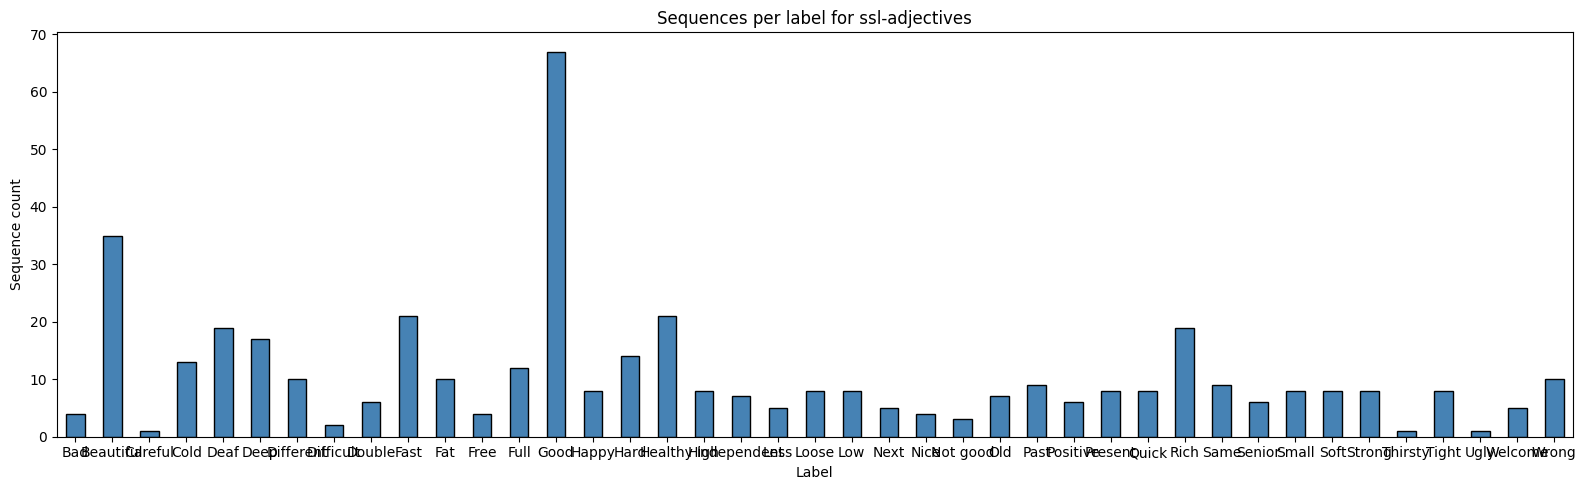


Min samples : 1 ( Careful )
Max samples : 67 ( Good )
Mean samples: 10


In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path(output_path)

with open(data_path, "rb") as f:
    ds = pickle.load(f)

X_train = ds["X_train"]
X_val   = ds["X_val"]
X_test  = ds["X_test"]
y_train = ds["y_train"]
y_val   = ds["y_val"]
y_test  = ds["y_test"]
le      = ds["label_encoder"]

print("Train shape:", X_train.shape)
print("Val shape  :", X_val.shape)
print("Test shape :", X_test.shape)

labels_all = np.concatenate([y_train, y_val, y_test])
print("Total sequences:", labels_all.shape[0])

labels_decoded = le.inverse_transform(labels_all.astype(int))
series = pd.Series(labels_decoded, name="label")
counts = series.value_counts().sort_index()

plt.figure(figsize=(16, 5))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title(f"Sequences per label for {SSL_NAME}")
plt.xlabel("Label")
plt.ylabel("Sequence count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMin samples :", counts.min(), "(", counts.idxmin(), ")")
print("Max samples :", counts.max(), "(", counts.idxmax(), ")")
print("Mean samples:", int(counts.mean()))